In [2]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [8]:
cd drive/MyDrive/EA979/

/content/drive/MyDrive/EA979


In [9]:
!7z x dataset.zip
!mv dataset/ photos/


7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.00GHz (50653),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan         1 file, 705976966 bytes (674 MiB)

Extracting archive: dataset.zip
 52% 4096 Open              --
Path = dataset.zip
Type = zip
Physical Size = 705976966

  0%      0% 36 - dataset/260382_dithering_red_yellow_black_white                                                           0% 50         0% 60         0% 68         0% 75         0% 79 - dataset/175807_futuro/237310_escada.jpg                                                 

In [10]:
# Instalando bibliotecas

!pip install pytorch-lightning torchinfo torchmetrics torch-summary torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 66.7 MB/s eta 0:00:00


In [11]:
# Importando bibliotecas

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
import pytorch_lightning as pl
from torch.optim import AdamW
import torchmetrics
from torchvision import models
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [13]:
# Definimos o redimensionamento para 224x224 (padrão de redes pré-treinadas)
# Isso resolve as variações de 375x500 e outras medidas
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # Normalização padrão ImageNet
])

# Carregando o dataset (42 pastas = 42 labels)
full_dataset = datasets.ImageFolder(root='photos', transform=transform)

# Divisão 80/20
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Número de classes: {len(full_dataset.classes)}") # Deve imprimir 42
print(f"Total de imagens: {len(full_dataset)}")         # Deve imprimir aprox. 7686

Número de classes: 42
Total de imagens: 7686


In [47]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Carrega a rede pré-treinada
model = models.resnet18(weights='DEFAULT')

# Ajusta a saída para as suas 42 classes
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 42)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Loop de treinamento super enxuto (apenas 3 épocas já devem bastar)
epochs = 10
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"Época {epoch+1}/{epochs} - Loss: {running_loss/len(train_loader):.4f}")

# Avaliação rápida
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Acurácia do modelo supervisionado: {100 * correct / total:.2f}%')

Época 1/10 - Loss: 1.1795
Época 2/10 - Loss: 0.6372
Época 3/10 - Loss: 0.5068
Época 4/10 - Loss: 0.4434
Época 5/10 - Loss: 0.3128
Época 6/10 - Loss: 0.3004
Época 7/10 - Loss: 0.2925
Época 8/10 - Loss: 0.2842
Época 9/10 - Loss: 0.3131
Época 10/10 - Loss: 0.1851
Acurácia do modelo supervisionado: 86.93%


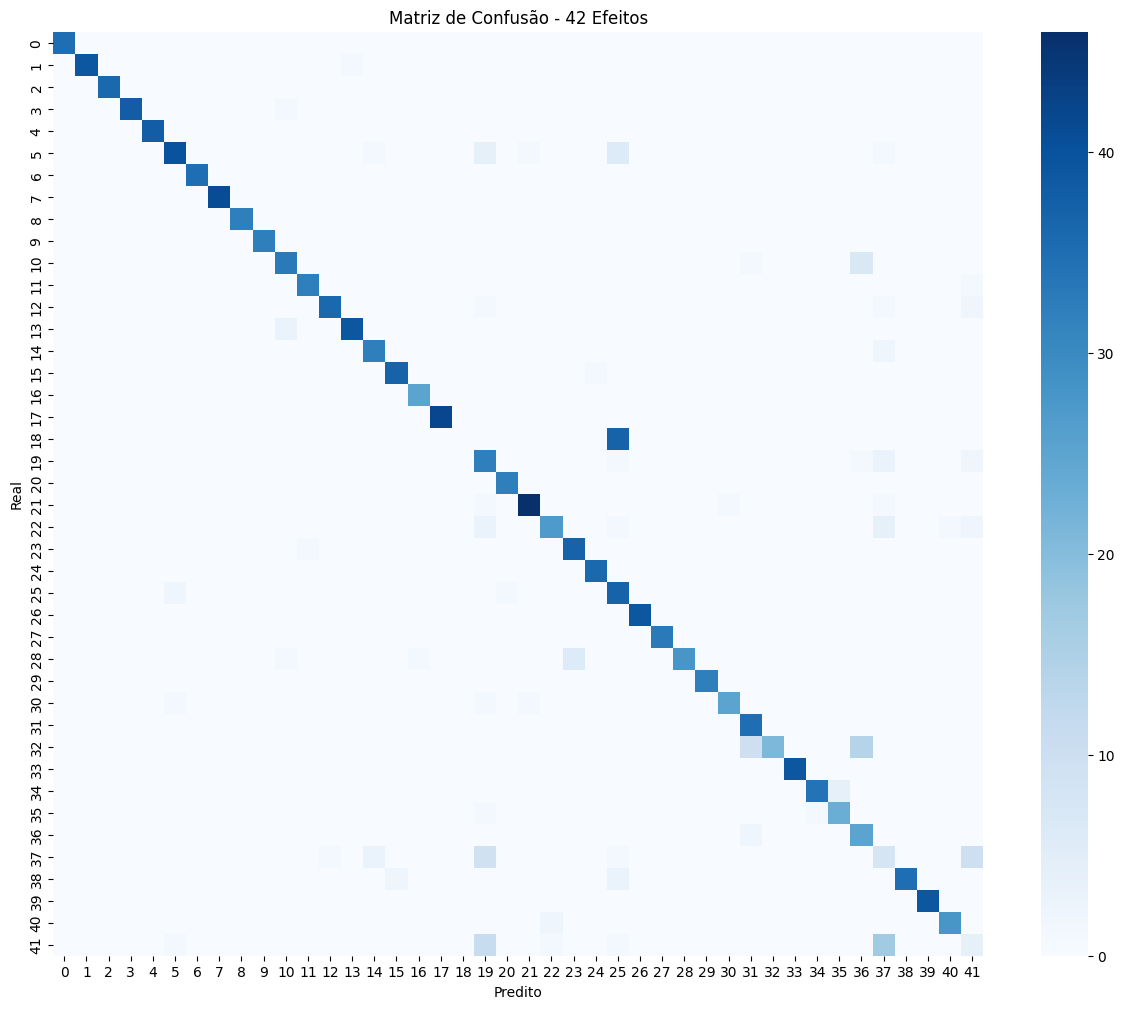

In [49]:

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Gera a matriz
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=False, cmap='Blues') # annot=False porque são muitas classes
plt.title('Matriz de Confusão - 42 Efeitos')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

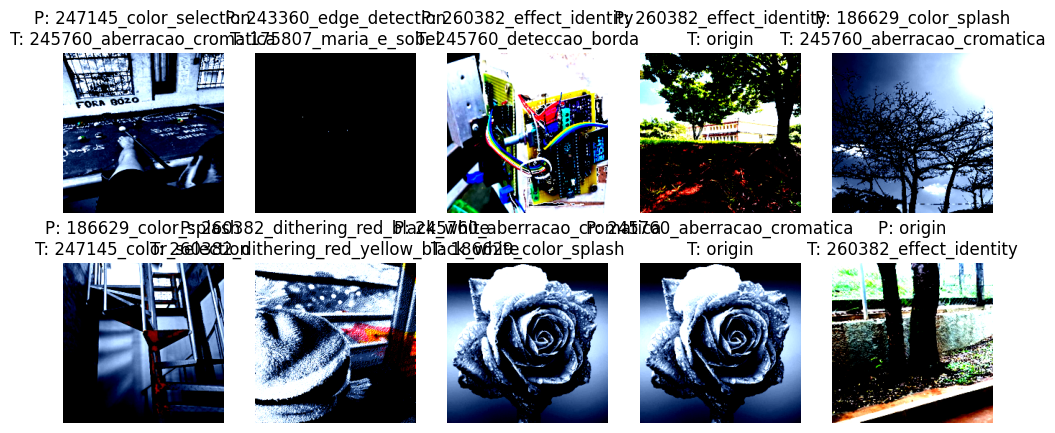

In [50]:
fig, axes = plt.subplots(2,5, figsize=(12,5))

for i, ax in enumerate(axes.flatten()):
    img, pred, true = errors[i]
    img = img.permute(1,2,0).numpy()

    ax.imshow(img)
    ax.set_title(f"P: {full_dataset.classes[pred]}\nT: {full_dataset.classes[true]}")
    ax.axis('off')

plt.show()

In [51]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Pegando features da rede (antes da última camada)
feature_extractor = torch.nn.Sequential(*list(model.children())[:-1])
feature_extractor.eval()

features = []
labels_list = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)

        features.append(feats.cpu().numpy())
        labels_list.extend(labels.numpy())

features = np.concatenate(features)

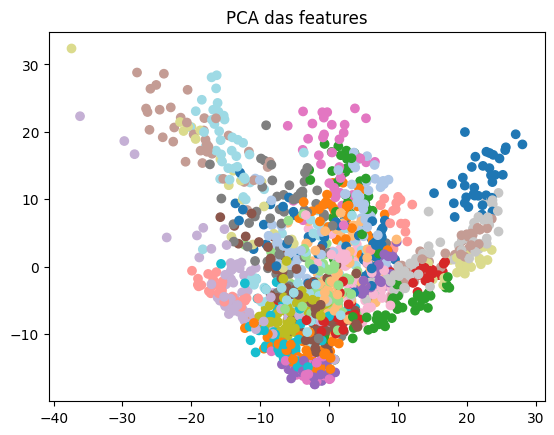

In [52]:
pca = PCA(n_components=2)
reduced = pca.fit_transform(features)

plt.scatter(reduced[:,0], reduced[:,1], c=labels_list, cmap='tab20')
plt.title("PCA das features")
plt.show()

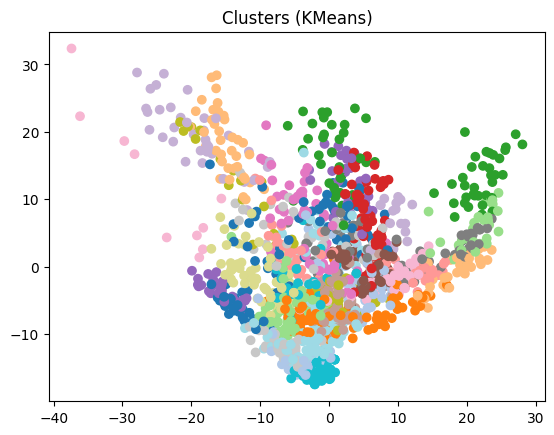

In [53]:
kmeans = KMeans(n_clusters=42)
clusters = kmeans.fit_predict(features)

plt.scatter(reduced[:,0], reduced[:,1], c=clusters, cmap='tab20')
plt.title("Clusters (KMeans)")
plt.show()